In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
data = pd.read_csv("clean_student_placement_dataset.csv")

In [22]:
data.head()

,age,highschool_gpa,college_gpa,internships,projects,certifications,hackathons,communication_skills,technical_skills,aptitude_score,...,attendance_percentage,backlogs,volunteering,english_proficiency,quantitative_score,logical_reasoning,extracurricular,leadership_experience,placed,experience_score
0,23,2.65,2.82,0,9,3,3,7,1,49,...,80.01,0,1,8,94,75,2,1,0,12
1,24,2.04,3.05,2,1,2,1,10,8,75,...,96.14,3,1,9,39,67,0,0,0,4
2,22,3.52,3.89,0,1,4,3,8,3,60,...,82.17,2,1,2,14,76,3,0,1,4
3,24,2.09,3.19,0,9,4,4,2,4,96,...,78.90,2,1,6,27,74,1,1,0,13
4,24,3.73,3.32,3,5,3,1,7,2,50,...,62.30,4,0,6,56,79,0,1,1,9


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [24]:
X = data.drop('placed', axis=1)
y = data['placed']

In [25]:
le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

y = le.fit_transform(y)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print("Training classes:", np.unique(y_train))
print("Testing classes:", np.unique(y_test))

Training classes: [0 1]
Testing classes: [0 1]


In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Logistic Regression

In [29]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9941666666666666


Decision Tree

In [30]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8866666666666667


Random Forest

In [31]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9258333333333333


Support Vector Machine

In [32]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.9683333333333334


KNN Model

In [33]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.8483333333333334


Model Comparison Table

In [34]:
models = ['Logistic Regression','Decision Tree','Random Forest','SVM','KNN']

accuracies = [
accuracy_score(y_test,y_pred_lr),
accuracy_score(y_test,y_pred_dt),
accuracy_score(y_test,y_pred_rf),
accuracy_score(y_test,y_pred_svm),
accuracy_score(y_test,y_pred_knn)
]

comparison = pd.DataFrame({
    'Model':models,
    'Accuracy':accuracies
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.994167
1        Decision Tree  0.886667
2        Random Forest  0.925833
3                  SVM  0.968333
4                  KNN  0.848333


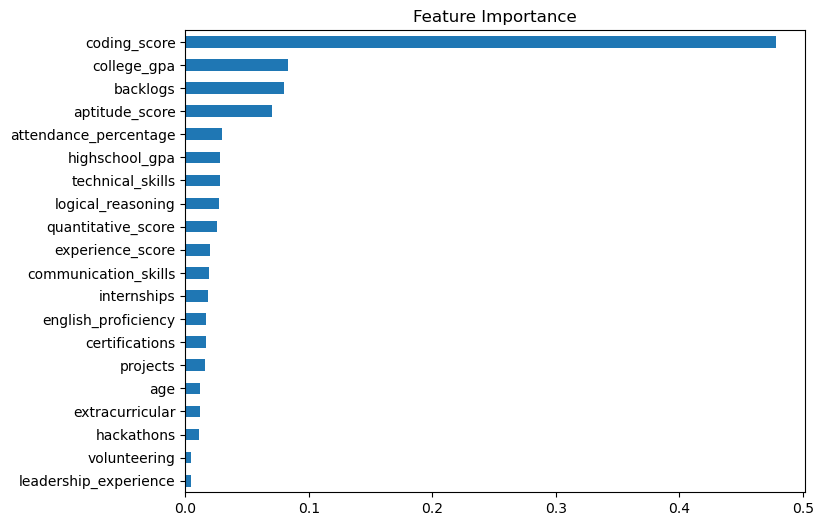

In [36]:
importance = rf.feature_importances_

features = pd.Series(importance, index=X.columns)

features.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

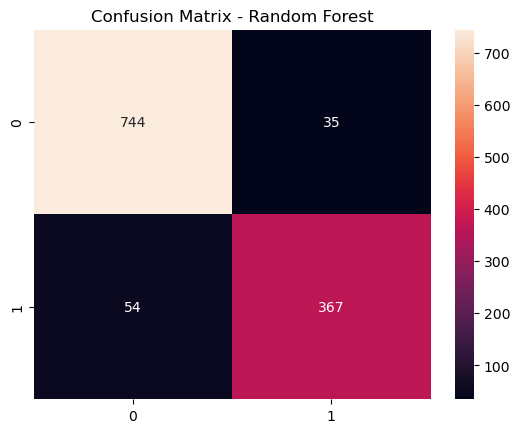

In [38]:
sns.heatmap(confusion_matrix(y_test,y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [39]:
import joblib

joblib.dump(rf, "placement_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [40]:
print(len(X.columns))
print(X.columns)

20
Index(['age', 'highschool_gpa', 'college_gpa', 'internships', 'projects',
       'certifications', 'hackathons', 'communication_skills',
       'technical_skills', 'aptitude_score', 'coding_score',
       'attendance_percentage', 'backlogs', 'volunteering',
       'english_proficiency', 'quantitative_score', 'logical_reasoning',
       'extracurricular', 'leadership_experience', 'experience_score'],
      dtype='object')
